# 3. Attention Mechanism Exploration

Trains and compares **4 specialised attention mechanisms** to determine which
behavioural aspect of network traffic best drives DDoS detection:

| Model | Focus | Heads | Depth |
|---|---|---|---|
| Temporal | Time-based patterns between flows | 8 | 4 |
| Protocol | Protocol-specific behaviours | 8 | 4 |
| Feature | Inter-feature relationships | 8 | 4 |
| Cross-Modal | Interactions across modalities | 8 | 4 |

Each model uses multi-task learning with three heads: binary, multiclass, and anomaly.

In [30]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
import warnings, time
warnings.filterwarnings('ignore')

from src.dataset import (
    create_flow_based_sequences,
    create_binary_labels,
    create_anomaly_scores,
    MultiTaskDataset,
)
from src.models import (
    TemporalAttentionTransformer,
    ProtocolAttentionTransformer,
    FeatureAttentionTransformer,
    CrossModalAttentionTransformer,
)
from src.training import train_attention_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 3.1 Prepare Data

In [31]:
DATA_DIR = '../data'
SEQ_LEN  = 64
BATCH    = 32

# Load
X_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_X.csv')
y_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_y.csv').squeeze()
X_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_X.csv')
y_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_y.csv').squeeze()

X_train.columns = X_train.columns.str.strip()
X_test.columns  = X_test.columns.str.strip()
for col in ['SimillarHTTP', 'SimilarHTTP']:
    if col in X_train.columns:
        X_train.drop(columns=[col], inplace=True)
        X_test.drop(columns=[col], inplace=True)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)
num_classes  = len(label_encoder.classes_)

# Sequences
X_seq_train, y_seq_train, proto_train, temp_train = create_flow_based_sequences(X_train, y_train_enc, seq_len=SEQ_LEN)
X_seq_test,  y_seq_test,  proto_test,  temp_test  = create_flow_based_sequences(X_test,  y_test_enc,  seq_len=SEQ_LEN)
feature_dim = X_seq_train.shape[-1]

# Multi-task labels
y_bin_train  = create_binary_labels(y_seq_train, label_encoder)
y_bin_test   = create_binary_labels(y_seq_test,  label_encoder)
y_anom_train = create_anomaly_scores(y_seq_train, label_encoder)
y_anom_test  = create_anomaly_scores(y_seq_test,  label_encoder)

# Data loaders
from torch.utils.data import DataLoader

train_ds = MultiTaskDataset(X_seq_train, proto_train, temp_train,
                            y_seq_train, y_bin_train, y_anom_train)
test_ds  = MultiTaskDataset(X_seq_test,  proto_test,  temp_test,
                            y_seq_test,  y_bin_test,  y_anom_test)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

print(f'Feature dim: {feature_dim} | Classes: {num_classes}')
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Feature dim: 43 | Classes: 13
Train batches: 96 | Test batches: 24


## 3.2 Instantiate Models

In [32]:
model_configs = {
    'Temporal':   TemporalAttentionTransformer,
    'Protocol':   ProtocolAttentionTransformer,
    'Feature':    FeatureAttentionTransformer,
    'CrossModal': CrossModalAttentionTransformer,
}

models = {}
for name, cls in model_configs.items():
    m = cls(feature_dim=feature_dim, embed_dim=128, num_heads=8,
            transformer_depth=4, num_classes=num_classes).to(device)
    params = sum(p.numel() for p in m.parameters())
    models[name] = m
    print(f'{name:12s} : {params:>10,} parameters')

Temporal     :  1,069,616 parameters
Protocol     :  1,094,704 parameters
Feature      :  1,167,312 parameters
CrossModal   :  1,391,632 parameters


## 3.3 Train All Models

In [33]:
EPOCHS = 10
all_results = {}

for name, model in models.items():
    print(f'\n{"="*60}')
    print(f'  Training: {name}')
    print(f'{"="*60}')
    results = train_attention_model(
        model, name, train_loader, test_loader,
        num_classes=num_classes, device=device, epochs=EPOCHS,
    )
    all_results[name] = results
    bm = results['best_metrics']
    print(f'  Best epoch {results["best_epoch"]} — '
          f'Bin F1={bm["binary_f1"]:.4f} | '
          f'MC F1={bm["multiclass_f1"]:.4f} | '
          f'Anom Corr={bm["anomaly_corr"]:.4f}')


  Training: Temporal
Epoch  1/10  loss=0.8264  bin_f1=0.9610  mc_f1=0.7848  anom=0.8715  combined=0.8550
Epoch  2/10  loss=0.3268  bin_f1=0.9802  mc_f1=0.8067  anom=0.9303  combined=0.8835
Epoch  3/10  loss=0.2403  bin_f1=0.9765  mc_f1=0.8439  anom=0.9336  combined=0.9016
Epoch  4/10  loss=0.2228  bin_f1=0.9776  mc_f1=0.8748  anom=0.9550  combined=0.9217
Epoch  5/10  loss=0.1959  bin_f1=0.9790  mc_f1=0.8832  anom=0.9536  combined=0.9260
Epoch  6/10  loss=0.1845  bin_f1=0.9803  mc_f1=0.8476  anom=0.9587  combined=0.9096
Epoch  7/10  loss=0.1686  bin_f1=0.9791  mc_f1=0.8828  anom=0.9556  combined=0.9263
Epoch  8/10  loss=0.1582  bin_f1=0.9842  mc_f1=0.8619  anom=0.9619  combined=0.9186
Epoch  9/10  loss=0.1623  bin_f1=0.9815  mc_f1=0.9087  anom=0.9387  combined=0.9365
Epoch 10/10  loss=0.1509  bin_f1=0.9804  mc_f1=0.9269  anom=0.9574  combined=0.9490
  Best epoch 10 — Bin F1=0.9804 | MC F1=0.9269 | Anom Corr=0.9574

  Training: Protocol
Epoch  1/10  loss=0.8984  bin_f1=0.9569  mc_f1=0.5

## 3.4 Compare Results

In [34]:
rows = []
for name, res in all_results.items():
    bm = res['best_metrics']
    rows.append({
        'Model': name,
        'Best Epoch': res['best_epoch'],
        'Binary F1': bm['binary_f1'],
        'Multiclass F1': bm['multiclass_f1'],
        'Anomaly Corr': bm['anomaly_corr'],
        'Combined Score': bm['combined_score'],
    })

comparison_df = pd.DataFrame(rows).sort_values('Combined Score', ascending=False)
print(comparison_df.to_string(index=False, float_format='%.4f'))

     Model  Best Epoch  Binary F1  Multiclass F1  Anomaly Corr  Combined Score
CrossModal           6     0.9816         0.9321        0.9666          0.9538
   Feature           9     0.9868         0.9250        0.9711          0.9528
  Temporal          10     0.9804         0.9269        0.9574          0.9490
  Protocol           9     0.9842         0.9225        0.9617          0.9488


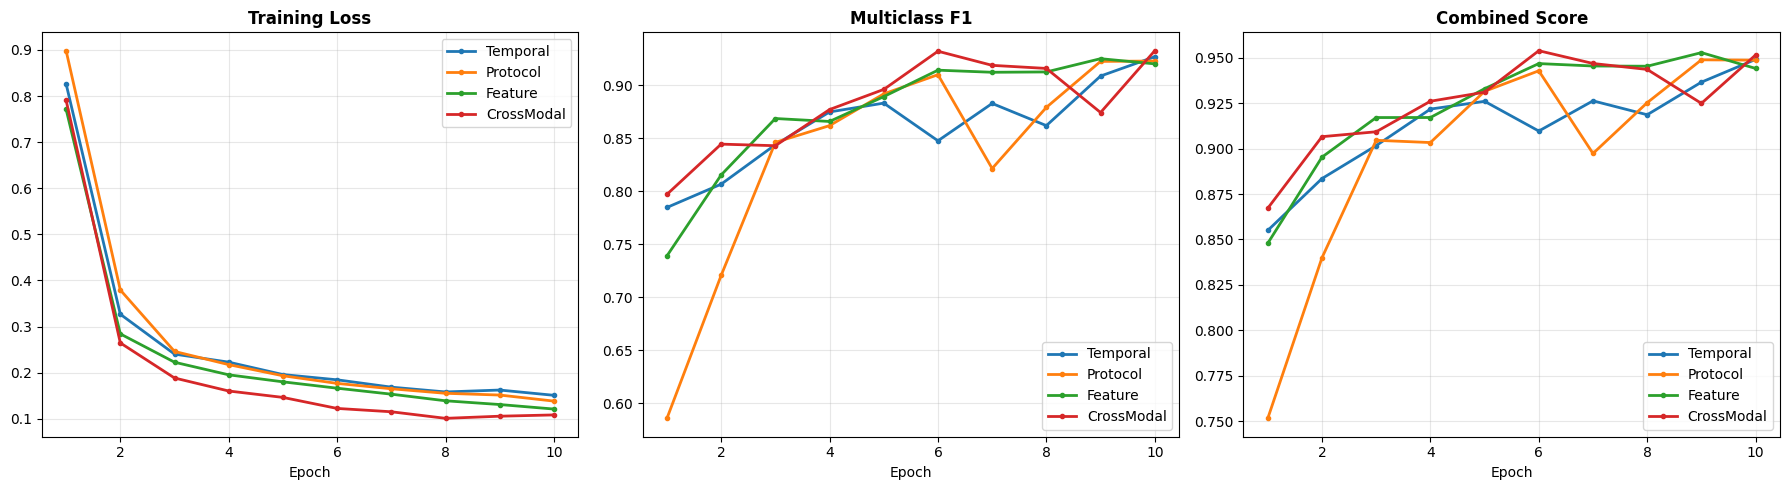

In [35]:
# Training curves — Combined Score over epochs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (name, res) in enumerate(all_results.items()):
    epochs = range(1, len(res['val_metrics']) + 1)

    # Training loss
    axes[0].plot(epochs, res['train_losses'], 'o-', color=colors[i],
                 label=name, linewidth=2, markersize=3)
    # Multiclass F1
    mc_f1 = [m['multiclass_f1'] for m in res['val_metrics']]
    axes[1].plot(epochs, mc_f1, 'o-', color=colors[i],
                 label=name, linewidth=2, markersize=3)
    # Combined score
    cs = [m['combined_score'] for m in res['val_metrics']]
    axes[2].plot(epochs, cs, 'o-', color=colors[i],
                 label=name, linewidth=2, markersize=3)

for ax, title in zip(axes, ['Training Loss', 'Multiclass F1', 'Combined Score']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/attention_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

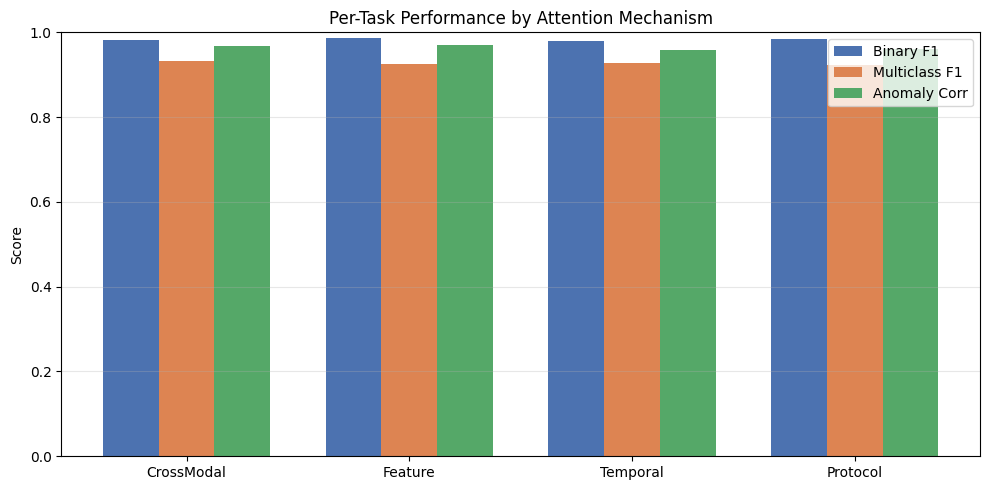

In [36]:
# Bar chart — per-task comparison
names = comparison_df['Model'].tolist()
x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, comparison_df['Binary F1'],     w, label='Binary F1',     color='#4c72b0')
ax.bar(x,     comparison_df['Multiclass F1'],  w, label='Multiclass F1', color='#dd8452')
ax.bar(x + w, comparison_df['Anomaly Corr'],   w, label='Anomaly Corr',  color='#55a868')

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Score')
ax.set_title('Per-Task Performance by Attention Mechanism')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/attention_per_task.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 Key Findings

| Rank | Model | Bin F1 | MC F1 | Anom Corr | Combined |
|---|---|---|---|---|---|
| 1 | Cross-Modal | 0.9816 | 0.9321 | 0.9666 | **0.9538** |
| 2 | Feature | 0.9868 | 0.9250 | 0.9711 | 0.9528 |
| 3 | Temporal | 0.9804 | 0.9269 | 0.9574 | 0.9490 |
| 4 | Protocol | 0.9842 | 0.9225 | 0.9617 | 0.9488 |

**Insight:** Cross-Modal attention ranks highest because it captures interactions between all three modalities (features, protocol, temporal) simultaneously,
giving it more signal than single-modality specialists.

The differences between models are small (~0.5 pp combined), which makes sense, they all
receive the same input and use the same transformer backbone. The specialist attention is
an additional inductive bias, not a completely different architecture.

These results inform the ensemble: the top 3 attention types (Temporal, Feature, Protocol) become the 3 expert networks, with Cross-Modal used as the baseline comparison.

**Next step → [04_ensemble_model.ipynb](04_ensemble_model.ipynb):** Combine the best attention mechanisms into an ensemble.